# Lecture 8: Introduction to stochastic processes

Any questions or comments to *milan.kloewer@physics.ox.ac.uk*
Many thanks to Myles Allen who lectured previous iterations of this material.

What we will cover today:

- Simple random processes and “white noise”.

- Stationarity, expectation, variance and co-variance

- Random walks, Brownian motion and “autoregressive” noise models.

Textbook: chapters 3 and 6 of Chris Chatfield, “The Analysis of Time Series: An Introduction” (6th Edition), Chapman and Hall, 2003. This is an excellent practical book for whatever you plan to do next, from MPhys projects to financial forecasting.

### Stochastic processes

You’ve heard how apparently unpredictable, random-looking behaviour can arise in low-dimensional deterministic chaotic systems like the quadratic map or the Lorenz '63 system of ODEs. In both cases, understanding the mathematics of the generating process revealed interesting things about it:
- How the changing stability of $n$-orbits leads to period-doubling in the quadratic map.
- Volume contraction in the Lorenz system showing it must occupy a less-than-3-dimensional attractor.
- Poincare-Bendixon theorem showing a non-repeating orbit must occupy a greater-than-2-dimensional attractor.


But we are ultimately interested in things we can _observe_, not just the behaviour of interesting sets of equations. Before concluding some random-looking behaviour has been generated by deterministic chaos, we have to understand what else might have generated it.

Most of the systems you will actually encounter will be much easier to characterise as linear stochastic processes than low-dimensional chaos. The theory of linear stochastic processes provides the basic workhorse tools for time-series analysis and most practical prediction.

### An archetypal random process

Let's start by considering the model

$$ x_{t+\delta t} = x_{t} + P \delta t \; \epsilon_t  $$

where 

$$ \epsilon_t \sim N(0, \sigma_{\epsilon}^2) $$

(the symbol $\sim$ meaning "is distributed as" or "drawn from") is a discrete sequence of normally distributed random shocks with zero mean and variance $\sigma_{\epsilon}^2$. So say you start with $x_0 = 0$ then on a given time step we may just add a (Gaussian) random number to it, or not, like

- 0, 0, add a random number, that random number, that random number, add another random number, that sum, add another random number, and so on

If $P$ being the probability per unit time of a shock occurring and $\delta t$ is sufficiently small that there is almost no chance of two shocks occurring in any time-interval, then $P \delta t$  is a random process that has a certain probability of being $1$ in a given time interval, and is $0$ otherwise.  

Text(0.5, 1.0, 'Random Gaussian shock process')

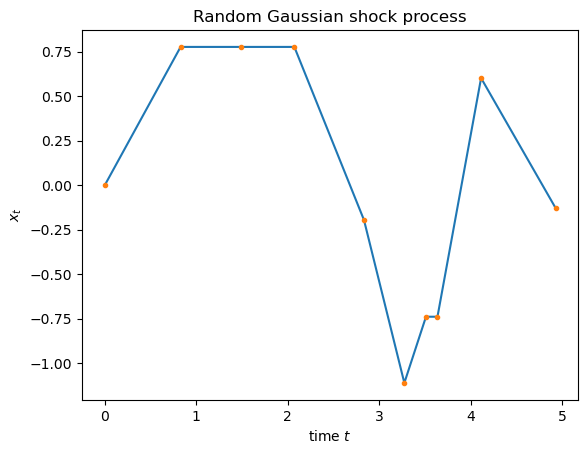

In [143]:
import numpy as np
import matplotlib.pyplot as plt

def random_shock_process(x0, p, σ, N):
    x = np.zeros(N)
    t = np.zeros(N)
    x[0] = x0    # set initial conditions
    t[0] = 0     # always start time axis at 0
    for i in range(N-1):
        δt = np.random.rand()    # increment time axis with some irregular step
        t[i+1] = t[i] + δt

        # decide whether to add a shock (or not)
        ϵₜ = σ*np.random.randn()
        Pδt = np.random.choice([1, 0], p=[p, 1-p])
        x[i+1] = x[i] + Pδt*ϵₜ

    return x, t

x, t = random_shock_process(x0 = 0, p=0.4, σ=1, N=10)

fig, ax = plt.subplots(1, 1)
ax.plot(t, x)
ax.plot(t, x, "C1o", ms=3) 
ax.set_xlabel(r"time $t$")
ax.set_ylabel(r"$x_t$")
ax.set_title("Random Gaussian shock process")

Notice how the appearance of the plot changes as we zoom in: this is *not* a self-similar process.

- For many steps $N$ of the process the randomness whether the shock occurs or not "averages out"
- For few steps $N$ it's apparent that the process can "stagnate" for several steps
- Also note how this process _drifts_ (while starting at 0 it doesn't stay around 0), why is that?

### The Discrete Random Walk

Although plausible-looking, this model is difficult to work with because it has two random elements: whether or not a shock occurs in any given time interval, and how large that shock is. Also note how we had a irregular time axis.

In the limit $P \delta t \gg 1$ a shock is almost certain to occur in a given sampling interval, so we can simplify. The variance of the  sum of the shocks in a given time interval $\delta t$ scales with their number, $P \delta t$, so the model becomes

$$ x_{t+\delta t} = x_{t} + \alpha \sqrt{\delta t} \; z_t $$ 

where $z_t \sim N(0,1)$ is a series of uncorrelated, unit-variance, normally-distributed random numbers, sometimes known as "white noise", and $\alpha^2 = P \sigma_{\epsilon}^2$. 

### Some definitions

- Expected value of $x$, $\langle x \rangle =$ the mean of an infinite sequence of realisations of $x$.

- Variance of a scalar: $\langle x^2 \rangle$

- Covariance between two scalars: $\langle x \, y \rangle$

- Expectation of an element of a vector: ${\langle {\bf{x}} \rangle}_i = \langle x_i \rangle$

- Covariance (matrix) between two  vectors: ${\bf{C}}_{{\bf{x}} {\bf{y}}} = {\langle {\bf{x}} {\bf{y}}^T \rangle}$

- Lag-covariance of a time-series $x_t$ at lag $k$: $c_k=\langle x_t \, x_{t+k} \rangle$

###  Properties of "white noise"

A discrete white noise process $z_t$ has some useful properties:

\begin{eqnarray*} \langle z_t \rangle & = & 0 \;\; \mbox{(zero mean)}\\
                  \langle {z_t}^2 \rangle & = & 1 \;\; \mbox{(unit variance)}\\
                  \langle z_t y_t \rangle & = & 0 \end{eqnarray*}
                  
where $y_t$ is *any* process which does not depend on $z_t$. 

In [128]:
N = 1000
z = np.random.randn(N)
np.mean(z)   # mean approaches 0

np.float64(-0.0018860232436787605)

In [129]:
np.var(z)    # variance approaches 1

np.float64(1.0057092243644112)

In [130]:
y = np.random.randn(N)
np.mean(z*y)   # mean of product of two processes is 0 (independent)

np.float64(-0.014566281981733752)

In [131]:
np.var(z*y)    # variance is 1 (because product is again a random process ...)

np.float64(1.0663707138978689)

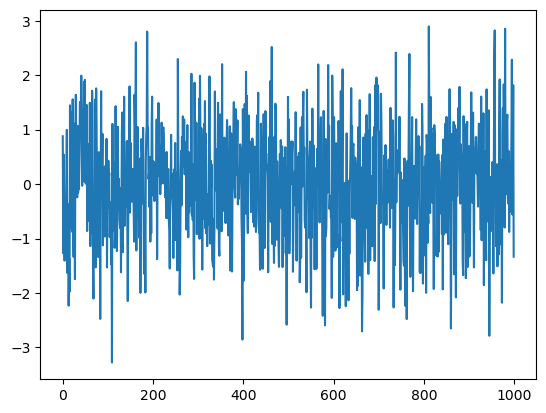

In [135]:
plt.plot(z)

### Discrete versus continuous processes

Back to the model:

$$ x_{t+\delta t} = x_{t} + \alpha \sqrt{\delta t} \; z_t . $$

Notice how strange things happen if we try and write the random walk model as a differential equation:

$$ \frac{\delta x}{\delta t} = \frac {\alpha \, z_t}{\sqrt{\delta t}} \;\; , $$

$ $which tends to infinity as $\delta t \rightarrow 0$. There is a fundamental sense in which stochastic processes are intrinsically discrete: perhaps this is one of the reasons Einstein had such difficulties with randomness in quantum mechanics, because it seems to conflict with the notion of a continuous universe.

### Brownian motion

The variance of the displacement between the start and end points of a random walk is just the expected square on the sum of the disturbances, which increases linearly with the number of steps. Hence a random walk is non-stationary, since its moments (mean, variance etc.) do not converge in the limit $t \rightarrow \infty$. To obtain as stationary process, one additional ingredient is needed:

$$ x_{t+\delta t} = x_{t} + P \delta t \; ( \epsilon_t - \mu x_t ) \;\; . $$

Where the additional term $-\mu x_t$ essentially "reduces" the added noise if $x_t$ is already large. So you may think of a _relaxation term_ that tries to pull this process back, or tries to prevent it from drifting when several $\epsilon_t$ of the same sign are being added consecutively, pushing the process away from its mean.

Or in the long-sampling-interval limit

$$ x_{t+\delta t} = (1 - \gamma \delta t) x_{t} + \alpha \sqrt{\delta t} \; z_t \;\; , $$

where $\gamma = P \mu$. If $x_t$ describes the *velocity* of a particle undergoing Brownian motion, what is the physical significance of $\mu$?

## Simple autoregressive processes

When looking at chaotic maps we defined the next iteration of the sequence as some (non-linear) function of the current iteration, i.e.

$$ x_{t} = f(x_{t-1})$$

Now the autoregressive random processes we want to investigate differ from these maps in two regards

- We make the map _linear_, i.e. $f(x_{t-1}) = a_1 x_{t-1}$, so the previous element is scaled by some constant $a_1$
- But we introduce noise to add randomness of the form $a_0 z_t$ where $a_0$ is some constant to scale the amplitude of the noise and $z_t$ is a random variable drawn from a distribution

We therefore have

$$ x_{t} = a_1 x_{t-1} + a_0 z_t , $$

and restrict ourselves to $z_t$ being a unit-variance white noise process with zero mean.

The AR(1) process (autoregressive 1st order) is the simplest physically plausible model of variability in almost all data-analysis problems involving regular sampling of a continuous system. This process is random but also depends on the previous time step. Remember how for the 1D discrete maps we looked at we always had $x_{i+1} = f(x_i)$ (the next time step is a function of the current) and similar argument holds for the continuous analogue $\dot{x} = f(x)$.

You can of course re-write this as 

$$ - a_1 x_{t-1} + x_{t} = a_0 z_t , $$

which is why Python statsmodels defines autoregressive (AR) coefficients as $\left[-a_p,...,1\right]$ (back to this later).


### Properties of an AR(1) process

The governing equation of an AR(1) process:
$$ x_t = a_0 z_t + a_1 x_{t-1} $$

We compute expected lag-covariances, $c_k \equiv \langle x_{t-k} x_t\rangle$, *assuming* the process is stationary with zero mean, by pre-multiplying by the various random sequences in equation (1) and taking expectations:
$$ \langle z_t x_t\rangle  = a_0 \langle z_t z_t\rangle  + a_1 \langle z_t x_{t-1}\rangle  = a_0 $$

$$ c_0 = \langle x_t x_t\rangle  = a_0 \langle x_t z_t\rangle  + a_1 \langle x_t x_{t-1}\rangle  = {a_0}^2 + a_1 c_1 $$

$$ c_1 = \langle x_{t-1} x_t\rangle  = a_0 \langle x_{t-1} z_t\rangle  + a_1 \langle x_{t-1} x_{t-1}\rangle  = a_1 c_0  $$

$$ c_k = \langle x_{t-k} x_t\rangle  = a_0 \langle x_{t-k} z_t\rangle  + a_1 \langle x_{t-k} x_{t-1}\rangle  = a_1
c_{k-1} \;\; .  $$

$$ c_0 = \frac{{a_0}^2}{1-{a_1}^2} $$

$$ c_k = c_0 {a_1}^k . $$

So we can fully determine the lag-covariances (the _covariance spectrum_) of an AR(1) process from the coefficients $a_0, a_1$. First, we get the lag-0 covariance $c_0$ and then we can obtain all other $c_k$ easily. Assuming $0 < a_1 < 1$ (the case $-1 < a_1 < 0$ is also interesting, what happens?) but we definitely want the $\| a_1 \| < 1$, otherwise it's not a stationary process (note the analogy to eigenvalues, stability of fixed points ...). Then we have that $c_1$ is some multiplicative constant smaller than $c_0$ and $c_2$ is, at the same ratio, smaller than $c_1$, so we have an exponential decay!

Let us verify this by sampling a process and comparing to this theoretical covariance spectrum!

Theoretical and actual variance: 5.263157894736843 5.289082845174344


Text(0.5, 1.0, 'Lag covariance')

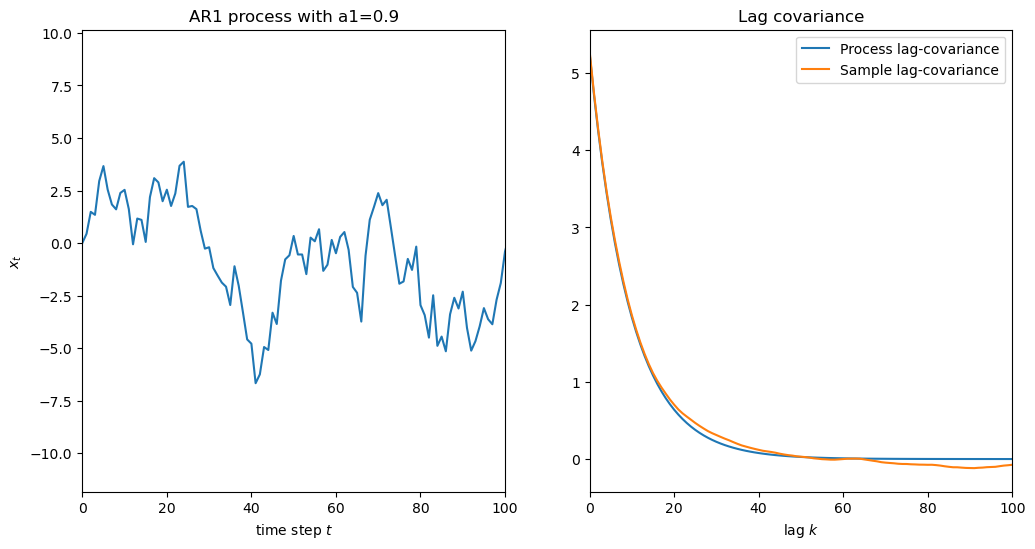

In [10]:
import numpy as np
import matplotlib.pyplot as plt

a0 = 1      # unit standard deviation for noise
a1 = 0.9    # lag-1 autocorrelation

# create AR1 process
N = 100000
x = np.zeros(N)
for i in range(N-1):
    zₜ = np.random.randn()
    x[i+1] = a0 * zₜ + a1 * x[i]

# process lag-covariance
c0 = a0**2 / (1 - a1**2)
ck = [c0 * a1**k for k in range(N)]

# Estimate the lag-covariance from the sample of process output
acv = np.convolve(x, x[::-1]) / N
acv = acv[N-1:]   # only the second half to start with lag 0

# compare the theoretical and estimate
print('Theoretical and actual variance:', ck[0], np.var(x))

# visualise
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, figsize = (12, 6))

ax1.plot(x)
ax2.plot(ck, label="Process lag-covariance")
ax2.plot(acv, label="Sample lag-covariance")

ax1.set_xlim(0, 100)
ax2.legend()
ax1.set_xlabel(r"time step $t$")
ax1.set_ylabel(r"$x_t$")
ax1.set_title("AR1 process with a1={}".format(a1))
ax2.set_xlabel(r'lag $k$')
ax2.set_title("Lag covariance")

#### Exercise: 

Sketch $c(k)$ for an AR(1) process in which (i) $a_0 = 2$, $a_1 = 0.8$; (ii) $a_0 = 2, a_1 = 0.3$; and (iii) $a_0 = 2, a_1=-0.8$. 

## The AR(p) Process

The obvious generalisation of the AR(1) process is the AR($p$) process

$$ x_t = a_0 z_t + a_1 x_{t-1} + a_2 x_{t-2} + \ldots + a_p x_{t-p} . $$

Multiplying both sides by $z_t$ and $x_{t-k: k=1, p}$ and taking expectations gives $p+1$ simultaneous equations relating lag-covariances $c_k$ and the process coefficients $a_i$. These are known as the ''Yule-Walker'' equations:

$$ \begin{eqnarray} c_0 & = & \sum_{i=1}^{p} a_i c_{i} + a_0^2 \\
c_k & = & \sum_{i=1}^{p} a_i c_{k-i} \;\; \mbox{for} \;\; k=1, p. \end{eqnarray} $$

These allow us to estimate the $c_k$ by observing process output, and hence derive the process coefficients. 
The crucial implication is that if you know $c_0$ to $c_p$ for an AR($p$) process, you can derive the process coefficients and hence *all there is to know* about it.  This is *not* true of non-linear processes.

### More on the AR(p) Process

While any individual realisation of an AR($p$) process is random, the process lag-covariance $c_k$ is not, and we can estimate it by taking successive realisations of the process, or chunks of the same realisation, and convolving them with each other. We can also use it to understand the properties of an AR($p$) process. Writing the Yule-Walker equations for $c_k$ where $k \ge 1$ in matrix-vector form

$$ {\bf c}_k = {\bf A} {\bf c}_{k-1} $$

where ${\bf c}_k$ is the vector $[c_k,c_{k-1},c_{k-2},...]$ the top row of ${\bf A}$ are the coefficients $a_1$ to $a_p$ and all other coefficients are zero apart from 1s in the first lower off-diagonal (check!). 

Successive application this recursive equation yields:

$$ {\bf c}_k = {\bf A}^k {\bf c}_{0} $$

Writing ${\bf A}$ in terms of its eigenvalues and eigenvectors:

$$ {\bf A} = {\bf E} {\bf \Lambda} {\bf E}^{-1} \mbox{  and  } {\bf A}^k = {\bf E} {\bf \Lambda}^k {\bf E}^{-1} $$

so 

$$c_k = \sum_{i=1}^p \epsilon_i \lambda_i^k = \sum_{i=1}^p \epsilon_i \exp(k \ln(\lambda_i))$$

Hence if any $|\lambda_i| \gt 1$ (bearing in mind the $\lambda_i$ may be complex), the covariance diverges for large $k$ and the process is unstable.


## Power Spectral Analysis

The commonest method of analysing linear stochastic processes is by examining at their power spectra. This makes sense because the power spectrum contains all there is to know about a linear stochastic process. It does not contain all there is to know about a non-linear process.

This is why you need to be careful with power spectra: the justification of interpreting data in terms of a power spectrum is deeply rooted in the linear stochastic model. If that model is physically inappropriate to the system you are examining, the power spectrum can be deeply misleading.

### What is the Power Spectrum? 
As the name implies, the power spectrum of a process $x_t$ is the expected power, or variance, as a function of frequency:

$$ h(\omega) = \langle | \sum_{k=0}^{M-1} x_{t+k} e^{i\omega k} |^2 \rangle $$

*If* the process is stationary, we can estimate the power spectrum by averaging over lots of segments of process output, each of length $M$:

$$ \widetilde{h}(\omega) = \frac{1}{N-M+1} \sum_{t=1}^{N-M+1} | \sum_{k=0}^{M-1} x_{t+k} e^{i\omega k} |^2 $$

This is approximately equal to

$$ \widehat{h}(\omega) =  \sum_{k=-M}^{M} w_k \hat{c}_k e^{i\omega k} $$

where $\widehat{c}_k$ is the estimated lag-$k$ covariance, and $w_k$ is a vector of weights

$$ \widehat{c}_k = \frac{1}{N-k} \sum_{t=1}^{N-k} x_t x_{t+k} . $$

### Estimating power spectra

$w_k$ is a symmetric "weighting function" which is unity at $k=0$ and tapers off to zero for $|k|>M$. Lots of weighting functions have been proposed, and statisticians get exercised about which are best, but it doesn't seem to make that much difference in most applications.

This is an application of the *correlation theorem*, which states that the Fourier transform of the cross-covariance of two series is equal (give or take a normalisation) to the product of the Fourier transform of one series with the complex conjugate of the Fourier transform of the other:

$$ (x_t \star y_t)(k) \equiv \int x_t y_{t+k} dt $$
$$ {\cal F}(x_t \star y_t) = {\cal F}^\ast(x_t) {\cal F}(y_t) $$

Note that the lag-covariance $c_k$ is the cross-covariance of $x_t$ with itself. So the power spectrum and the lag-covariance function are essentially two ways of displaying the same information. 

### The spectrum of an AR(p) process:

$$ h(\omega)_{\mbox{AR($p$)}} = 
\frac{a_0^2}{|1 - a_1 e^{-i\omega} - a_2 e^{-2i\omega} - \ldots |^2} . $$

Given that the covariance function $c_k$ for an AR($p$) process was defined implicitly through the Yule-Walker equations, this may seem astonishingly simple. The proof is rather involved, you don't need to prove it, or even remember it (although you might like to think about some special cases for low-order AR models).

#### Exercise:

Show that for a random walk ($a_1 = 1$, all higher terms zero), $h(\omega) = a_0^2 \omega^{-2}$ as $\omega \rightarrow 0$: this $-2$ "power law" behaviour emerging in the high-frequency limit is a hall-mark of random-walk-type processes.


Text(0.5, 1.0, 'Power spectrum AR(1) process')

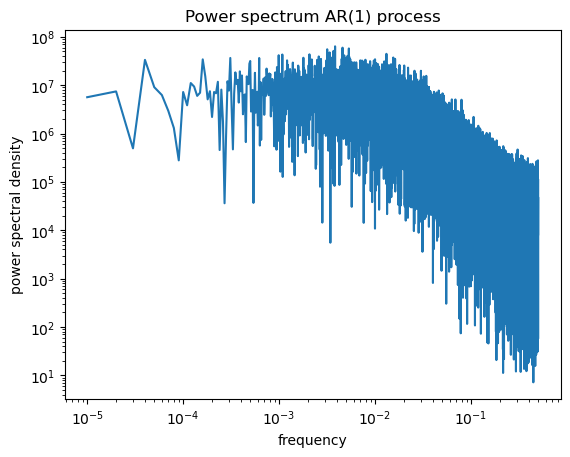

In [14]:
# compute the power spectrum
ω = np.fft.rfftfreq(len(x), d=1)    # sample spacing (1 per time period)
power = np.abs(np.fft.rfft(x))**2   # power

# visualise on a log-log plot
plt.loglog(ω[1:], power[1:])
plt.xlabel('frequency')
plt.ylabel('power spectral density')
plt.title('Power spectrum AR(1) process')